<a href="https://colab.research.google.com/github/daudkhan8/AI-CEP-Hot_Dog-Classifier/blob/main/HotDog_Classifier_Daud_23408.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/AI CEP/archive.zip" -d "/content/"

Archive:  /content/drive/MyDrive/AI CEP/archive.zip
  inflating: /content/seefood/test/hot_dog/133012.jpg  
  inflating: /content/seefood/test/hot_dog/133015.jpg  
  inflating: /content/seefood/test/hot_dog/133245.jpg  
  inflating: /content/seefood/test/hot_dog/135628.jpg  
  inflating: /content/seefood/test/hot_dog/138933.jpg  
  inflating: /content/seefood/test/hot_dog/138937.jpg  
  inflating: /content/seefood/test/hot_dog/138969.jpg  
  inflating: /content/seefood/test/hot_dog/139177.jpg  
  inflating: /content/seefood/test/hot_dog/142835.jpg  
  inflating: /content/seefood/test/hot_dog/143012.jpg  
  inflating: /content/seefood/test/hot_dog/144956.jpg  
  inflating: /content/seefood/test/hot_dog/146227.jpg  
  inflating: /content/seefood/test/hot_dog/146834.jpg  
  inflating: /content/seefood/test/hot_dog/147874.jpg  
  inflating: /content/seefood/test/hot_dog/152106.jpg  
  inflating: /content/seefood/test/hot_dog/154409.jpg  
  inflating: /content/seefood/test/hot_dog/154545.jp

In [3]:
!ls "/content/drive/MyDrive/AI CEP/"

archive.zip


In [8]:
!ls /content/train/not_hot_dog/

100135.jpg  134598.jpg	178804.jpg  219778.jpg	303809.jpg  824157.jpg
100148.jpg  136985.jpg	179038.jpg  222138.jpg	309651.jpg  828189.jpg
100274.jpg  138514.jpg	180453.jpg  222586.jpg	311779.jpg  835998.jpg
100945.jpg  138754.jpg	181579.jpg  223676.jpg	319830.jpg  837058.jpg
101312.jpg  139291.jpg	181677.jpg  223944.jpg	320734.jpg  846311.jpg
102037.jpg  140292.jpg	182516.jpg  225525.jpg	322067.jpg  89197.jpg
102197.jpg  140832.jpg	182658.jpg  225804.jpg	331674.jpg  89502.jpg
102813.jpg  141320.jpg	183313.jpg  230015.jpg	333385.jpg  89892.jpg
103010.jpg  143158.jpg	184954.jpg  232844.jpg	338101.jpg  89974.jpg
105375.jpg  143685.jpg	185190.jpg  233172.jpg	4176.jpg    90116.jpg
105647.jpg  143994.jpg	187087.jpg  234706.jpg	4770.jpg    90167.jpg
106608.jpg  145012.jpg	188505.jpg  236973.jpg	4781.jpg    90481.jpg
107013.jpg  146029.jpg	189482.jpg  238410.jpg	4889.jpg    90923.jpg
107216.jpg  146910.jpg	189787.jpg  239724.jpg	5762.jpg    90930.jpg
107312.jpg  147312.jpg	191085.jpg  240760.j

In [10]:
!ls /content/train/hot_dog/

1000288.jpg  1161755.jpg  127117.jpg   3637190.jpg  3789737.jpg  867751.jpg
1011661.jpg  116486.jpg   127252.jpg   3639855.jpg  3798465.jpg  867991.jpg
1013916.jpg  1166403.jpg  1282229.jpg  3642871.jpg  3802333.jpg  869853.jpg
1017226.jpg  1166929.jpg  1282523.jpg  3645373.jpg  3811761.jpg  884796.jpg
1018245.jpg  1174926.jpg  129092.jpg   3646755.jpg  3814644.jpg  888267.jpg
1023510.jpg  117749.jpg   1301907.jpg  3655069.jpg  3835641.jpg  891949.jpg
1040579.jpg  1179964.jpg  1308699.jpg  3655420.jpg  3838014.jpg  893274.jpg
1046526.jpg  1182402.jpg  1308879.jpg  3660087.jpg  3840582.jpg  893996.jpg
1051628.jpg  1182518.jpg  1313978.jpg  3684539.jpg  3842701.jpg  898576.jpg
1051643.jpg  1183508.jpg  1322860.jpg  3690427.jpg  3843212.jpg  907088.jpg
1051711.jpg  1183725.jpg  1335350.jpg  3690925.jpg  3844876.jpg  910098.jpg
1053879.jpg  1186993.jpg  1336262.jpg  3690.jpg     3846249.jpg  910827.jpg
1055689.jpg  118875.jpg   1344141.jpg  3692506.jpg  3847258.jpg  916396.jpg
1057517.jpg 

In [12]:
train_path = "/content/train"
test_path = "/content/test"

In [13]:
import os
print(len(os.listdir(os.path.join(train_path, "hot_dog"))))
print(len(os.listdir(os.path.join(train_path, "not_hot_dog"))))

249
249


In [14]:
test_hot = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not = len(os.listdir(os.path.join(test_path, "not_hot_dog")))
print(f"Test hot dogs: {test_hot}")
print(f"Test not hot dogs: {test_not}")

Test hot dogs: 250
Test not hot dogs: 250


In [15]:
import numpy as np
import matplotlib . pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow . keras import layers
from tensorflow . keras . preprocessing . image import ImageDataGenerator
import os
import random
print (" Libraries loaded successfully !")
print (" TensorFlow version :", tf . __version__ )


 Libraries loaded successfully !
 TensorFlow version : 2.20.0


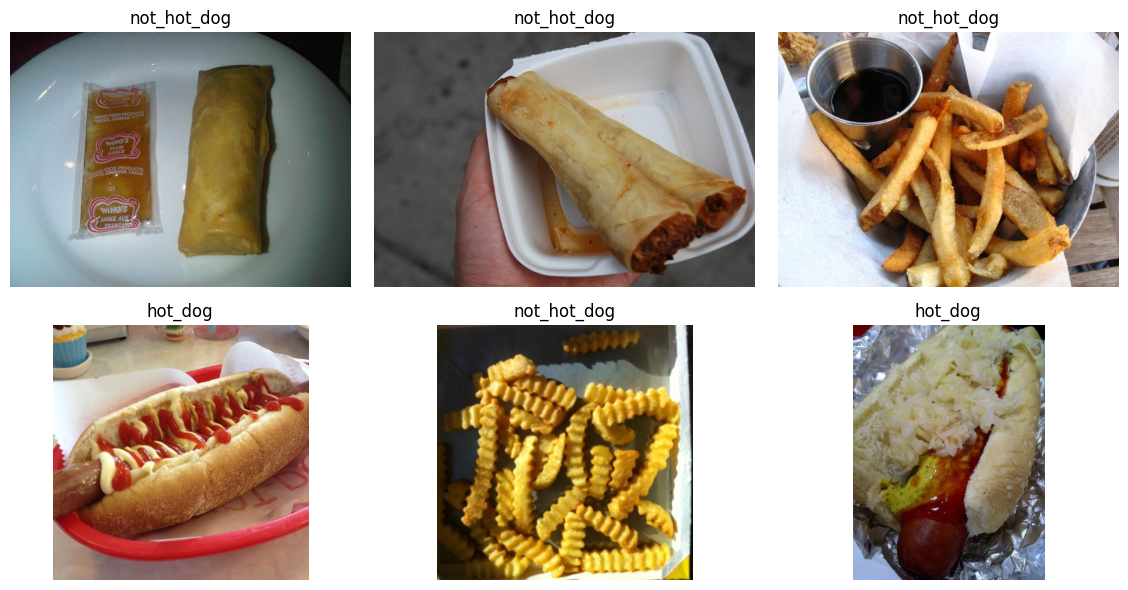

Image shape: (512, 384, 3)


In [19]:
# Display 6 random images
plt . figure ( figsize =(12 , 6) )
for i in range (6) :
    # Pick random class
    class_name = random . choice (["hot_dog", "not_hot_dog"])
    class_path = os . path . join ( train_path , class_name )
    img_name = random . choice ( os . listdir ( class_path ) )
    img_path = os . path . join ( class_path , img_name )
    # Load and show image
    img = plt . imread ( img_path )
    plt . subplot (2 , 3 , i +1)
    plt . imshow ( img )
    plt . title ( class_name )
    plt . axis ('off')
    plt . tight_layout ()
plt . show ()
print("Image shape:", img.shape)

In [21]:
# Set image size ( YOUR CHOICE : 64 x64 is faster , 128 x128 is more accurate
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32
# Create generators with automatic labeling
train_datagen = ImageDataGenerator (
rescale =1./255 , # Normalize pixel values from 0 -255 to 0 -1
validation_split =0.2 # Use 20% of training data for validation
)
train_generator = train_datagen . flow_from_directory (
train_path ,
target_size =( IMG_HEIGHT , IMG_WIDTH ) ,
batch_size = BATCH_SIZE ,
class_mode ='binary', # Binary classification (hot dog vs not)
subset ='training'  # Training set (80% of data )
)
validation_generator = train_datagen . flow_from_directory (
train_path ,
target_size =( IMG_HEIGHT , IMG_WIDTH ) ,
batch_size = BATCH_SIZE ,
class_mode ='binary',
subset ='validation' # Validation set (20% of data )
)
# YOUR CODE HERE : Print the class labels
#
# Hint : Print train_generator . class_indices


Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.


In [23]:
# Build a simple ANN
ann_model = keras . Sequential ([
# Flatten the 2D image into 1D
layers . Flatten ( input_shape =( IMG_HEIGHT , IMG_WIDTH , 3) ) ,
# Dense layers
layers . Dense (128 , activation ='relu') ,
layers . Dense (64 , activation ='relu' ) ,
layers . Dense (1 , activation ='sigmoid') # Output : probability ofhot dog"
])
# Compile the model
ann_model . compile ( optimizer ='adam' , loss ='binary_crossentropy',
metrics =[ 'accuracy'])
# Show model summary
ann_model . summary ()
# Train for 10 epochs
history_ann = ann_model . fit ( train_generator , validation_data =
validation_generator , epochs =10)
# YOUR CODE HERE : Plot training vs validation accuracy .
#
#
# Hint : Use
# plt. plot ( history_ann . history [ ’ XXXX ’] , label = ’ XXXX ’)
# plt. plot ( history_ann . history [ ’ XXXX ’] , label = ’ XXXX ’)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.4650 - loss: 1.8200 - val_accuracy: 0.4898 - val_loss: 0.8102
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5800 - loss: 0.7254 - val_accuracy: 0.5306 - val_loss: 0.8357
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5975 - loss: 0.7219 - val_accuracy: 0.5102 - val_loss: 1.0667
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5475 - loss: 0.8035 - val_accuracy: 0.5000 - val_loss: 0.8304
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6050 - loss: 0.6991 - val_accuracy: 0.5408 - val_loss: 0.9277
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6575 - loss: 0.6051 - val_accuracy: 0.5306 - val_loss: 0.8722
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6625 - loss: 0.6022 - val_accuracy: 0.5306 - val_loss: 0.8163
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.6975 - loss: 0.5814 - val_accuracy: 0.5510 - v

In [27]:
cnn_model = keras . Sequential ([
# First Conv layer : 32 filters , 3x3 kernel
layers . Conv2D (32 , (3 , 3) , activation ='relu', input_shape =(
IMG_HEIGHT , IMG_WIDTH , 3) ) ,
layers . MaxPooling2D ((2 , 2) ) ,
# Second Conv layer : 64 filters
layers . Conv2D (64 , (3 , 3) , activation ='relu') ,
layers . MaxPooling2D ((2 , 2) ) ,
# Third Conv layer ( YOUR TURN ): Add 64 filters with 3x3 kernel ,followed by Max pooling
layers . Conv2D (64 , (3 , 3) , activation ='relu') ,
layers . MaxPooling2D ((2 , 2) ) ,
# Flatten and dense layers
layers . Flatten () ,
layers . Dense (64 , activation ='relu' ) ,
layers . Dense (1 , activation ='sigmoid')
])
# Compile ( copy from ANN)
cnn_model . compile ( optimizer ='adam' , loss ='binary_crossentropy',
metrics =[ 'accuracy'])
# Train the CNN
history_cnn = cnn_model . fit ( train_generator , validation_data =
validation_generator , epochs =15)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.5200 - loss: 0.6974 - val_accuracy: 0.5816 - val_loss: 0.6907
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - accuracy: 0.5700 - loss: 0.6869 - val_accuracy: 0.5714 - val_loss: 0.6801
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.6425 - loss: 0.6669 - val_accuracy: 0.5816 - val_loss: 0.6520
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.6200 - loss: 0.6459 - val_accuracy: 0.5510 - val_loss: 0.6718
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.6825 - loss: 0.6136 - val_accuracy: 0.6327 - val_loss: 0.6578
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.6850 - loss: 0.5879 - val_accuracy: 0.6224 - val_loss: 0.6688
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.7350 - loss: 0.5361 - val_accuracy: 0.6429 - val_loss: 0.6879
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.7625 - loss: 0.5119 - val_accuracy: 0.6531 - val_

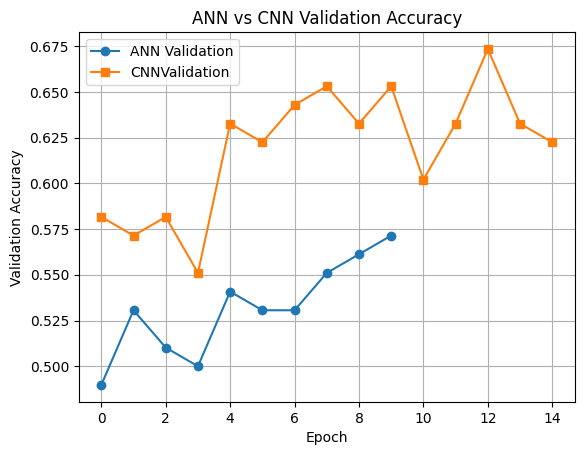

In [30]:
plt . plot ( history_ann . history ['val_accuracy' ] , label ='ANN Validation', marker ='o')
plt . plot ( history_cnn . history ['val_accuracy'] , label ='CNNValidation' , marker ='s')
plt . xlabel ('Epoch')
plt . ylabel ('Validation Accuracy')
plt . legend ()
plt . title ('ANN vs CNN Validation Accuracy')
plt . grid ( True )
plt . show ()

In [32]:
from tensorflow . keras import regularizers
# Add dropout of 0.25 , 0.25 , and 0.5 after each MaxPooling layer
# respectively
improved_model = keras . Sequential ([
layers . Conv2D (32 , (3 , 3) , activation ='relu' , input_shape =(
IMG_HEIGHT , IMG_WIDTH , 3) ) ,
layers . MaxPooling2D ((2 , 2) ) ,
layers . Dropout (0.25) , # Add dropout 0.25
layers . Conv2D (64 , (3 , 3) , activation ='relu' ) ,
layers . MaxPooling2D ((2 , 2) ) ,
layers . Dropout (0.25) , # Add dropout 0.25
layers . Conv2D (64 , (3 , 3) , activation ='relu' ) ,
layers . MaxPooling2D ((2 , 2) ) ,
layers . Flatten () ,
layers . Dense (64 , activation ='relu' ) ,
layers . Dropout (0.5) , # Add dropout 0.5 before output
layers . Dense (1 , activation ='sigmoid' )
])
# Recompile and Train the improved model ( after addressing overfitting
# using dropout )
improved_model . compile ( optimizer ='adam' , loss ='binary_crossentropy' ,
metrics =[ 'accuracy' ])
history_improved = improved_model . fit ( train_generator , validation_data
= validation_generator , epochs =15)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.4900 - loss: 0.7096 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.4725 - loss: 0.6985 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - accuracy: 0.5075 - loss: 0.6909 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.5325 - loss: 0.6926 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.5050 - loss: 0.6949 - val_accuracy: 0.4898 - val_loss: 0.6931
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.4925 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 0.5525 - loss: 0.6914 - val_accuracy: 0.4898 - val_loss: 0.6928
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - accuracy: 0.5300 - loss: 0.6918 - val_accuracy: 0.5102 - val_

In [34]:
augmented_datagen = ImageDataGenerator (
rescale =1./255 ,
rotation_range =20 ,
width_shift_range =0.1 ,
height_shift_range =0.1 ,
horizontal_flip = True ,
validation_split =0.2
)
train_augmented = augmented_datagen . flow_from_directory (
train_path ,
target_size =( IMG_HEIGHT , IMG_WIDTH ) ,
batch_size = BATCH_SIZE ,
class_mode ='binary',
subset ='training' )
# Then retrain the improved model with augmented_datagen
final_model = keras . Sequential ([
# Same architecture as improved_model
layers . Conv2D (32 , (3 , 3) , activation ='relu', input_shape =(
IMG_HEIGHT , IMG_WIDTH , 3) ) ,
layers . MaxPooling2D ((2 , 2) ) ,
layers . Dropout (0.25) ,
layers . Conv2D (64 , (3 , 3) , activation ='relu') ,
layers . MaxPooling2D ((2 , 2) ) ,
layers . Dropout (0.25) ,
layers . Conv2D (64 , (3 , 3) , activation ='relu' ) ,
layers . MaxPooling2D ((2 , 2) ) ,
layers . Flatten () ,
layers . Dense (64 , activation ='relu' ) ,
layers . Dropout (0.5) ,
layers . Dense (1 , activation ='sigmoid' )])
final_model . compile (optimizer ='adam', loss ='binary_crossentropy', metrics =['accuracy'])
history_final = final_model . fit ( train_augmented , validation_data =validation_generator , epochs =15)

Found 400 images belonging to 2 classes.
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - accuracy: 0.4900 - loss: 0.7190 - val_accuracy: 0.4898 - val_loss: 0.6930
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - accuracy: 0.4500 - loss: 0.6968 - val_accuracy: 0.5102 - val_loss: 0.6932
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.5050 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 209ms/step - accuracy: 0.4950 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.5200 - loss: 0.6913 - val_accuracy: 0.5204 - val_loss: 0.6917
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.5875 - loss: 0.6854 - val_accuracy: 0.5204 - val_loss: 0.6882
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.5225 - loss: 0.6942 - val_accuracy: 0.5408 - val_loss: 0.6828
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step - accuracy: 0.5300 - loss: 0.6834 - val_accuracy: 0.6327 - val_

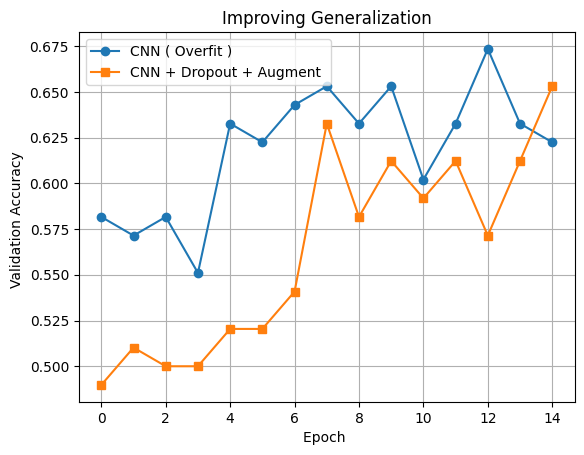

In [36]:
plt . plot ( history_cnn . history ['val_accuracy'] , label ='CNN ( Overfit )',
marker ='o')
plt . plot ( history_final . history ['val_accuracy'] , label ='CNN + Dropout + Augment ', marker ='s')
plt . xlabel ('Epoch ')
plt . ylabel ('Validation Accuracy ')
plt . legend ()
plt . title ('Improving Generalization')
plt . grid ( True )
plt . show ()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
 NOT A HOT DOG! ( confidence : 0.56)


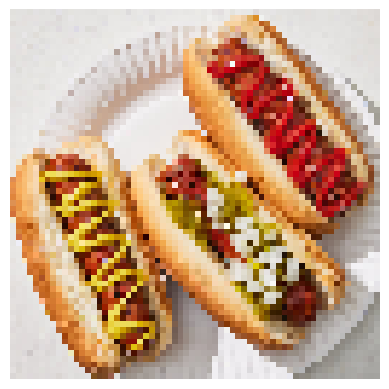

In [57]:
from tensorflow . keras . preprocessing import image
import requests
from io import BytesIO
def predict_image ( img_url ) :
    # Download image
    response = requests . get ( img_url )
    img = image . load_img ( BytesIO ( response . content ) , target_size =(
    IMG_HEIGHT , IMG_WIDTH ) )
    img_array = image . img_to_array ( img )
    img_array = np . expand_dims ( img_array , axis =0) / 255.0
    # Predict
    prediction = final_model . predict ( img_array ) [0][0]
    if prediction > 0.50:
        print ( f" HOT DOG! ( confidence : { prediction :.2f})")
    else :
        print ( f" NOT A HOT DOG! ( confidence : {1 - prediction :.2f})")
    # Show image
    plt . imshow ( img )
    plt . axis ('off')
    plt . show ()
# Test on a hot dog image URL ( find one on Google Images )
predict_image ("https://static01.nyt.com/images/2024/06/28/multimedia/28GRILL-HOTDOGS-REX-cqwj/01GRILL-HOTDOGS-REX-cqwj-mediumSquareAt3X.jpg") # REPLACE WITH REAL URL


image 1/1 /content/test/hot_dog/704107.jpg: 640x640 1 person, 2 hot dogs, 153.1ms
Speed: 2.8ms preprocess, 153.1ms inference, 4.3ms postprocess per image at shape (1, 3, 640, 640)


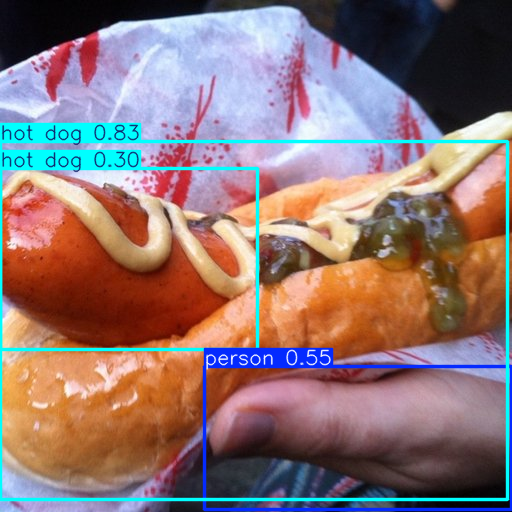

In [64]:
! pip install ultralytics -q
from ultralytics import YOLO
import os
import random

# Load a tiny pre-trained model
yolo_model = YOLO("yolov8n.pt") # n = nano (fast, small )

# Get a path to a hot dog image from the test set
test_hotdog_dir = os.path.join(test_path, "hot_dog")
hotdog_image_name = random.choice(os.listdir(test_hotdog_dir))
hotdog_image_path = os.path.join(test_hotdog_dir, hotdog_image_name)

# Run detection on your hot dog image
results = yolo_model(hotdog_image_path)

# Show results (it will draw boxes around objects it recognizes )
results[0].show()